# Training Computer Vision Models

## Loading Database

In [1]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

def get_dataloaders(data_dir,
                    train_dir='train',
                    test_dir='test',
                    val_dir = 'val',
                    batch_size=32,
                    image_size=224,
                    mean=None,
                    std=None,
                    num_workers=0,
                    pin_memory=True):
    """
    Returns train, val, and test DataLoaders using ImageFolder layout:
      data_dir/train/<class>/*.jpg
      data_dir/test/<class>/*.jpg
      data_dir/val/<class>/*.jpg

    Defaults to ImageNet normalization if mean/std not provided.
    """
    if mean is None:
        mean = [0.485, 0.456, 0.406]
    if std is None:
        std = [0.229, 0.224, 0.225]

    # Ensure small images are upscaled before cropping to avoid size errors
    train_transforms = transforms.Compose([
        transforms.Resize(256),
        transforms.RandomResizedCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    val_transforms = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    train_path = os.path.join(data_dir, train_dir)
    test_path = os.path.join(data_dir, test_dir)
    val_path = os.path.join(data_dir, val_dir)

    train_dataset = datasets.ImageFolder(train_path, transform=train_transforms)
    val_dataset = datasets.ImageFolder(val_path, transform=val_transforms)
    test_dataset = datasets.ImageFolder(test_path, transform=val_transforms)

    train_loader = DataLoader(train_dataset,
                              batch_size=batch_size,
                              shuffle=True,
                              num_workers=num_workers,
                              pin_memory=pin_memory)
    
    val_loader = DataLoader(val_dataset,
                            batch_size=batch_size,
                            shuffle=False,
                            num_workers=num_workers,
                            pin_memory=pin_memory)
    
    test_loader = DataLoader(test_dataset,
                             batch_size=batch_size,
                             shuffle=False,
                             num_workers=num_workers,
                             pin_memory=pin_memory)
    
    return train_loader, val_loader, test_loader, train_dataset.classes

In [2]:
train_loader, val_loader, test_loader, classes = get_dataloaders('../data/Nutrition_dataset', batch_size=32, image_size=224)

print(f"Train samples: {len(train_loader.dataset)}")
print(f"Test samples: {len(test_loader.dataset)}")
print(f"Validation samples: {len(val_loader.dataset)}")

Train samples: 7056
Test samples: 882
Validation samples: 882


## Optimizing Hyperparemeters

In [3]:
import optuna
import sys
sys.path.append("../")
import importlib
from utils import image_models
importlib.reload(image_models)
import torch
import torch.nn as nn

c:\Users\gnoceras\Documents\HackIL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
# Use existing loaders and class list
subset_fraction = 0.2
num_classes = len(classes)

train_dataset = train_loader.dataset
val_dataset = val_loader.dataset

train_indices = torch.randperm(len(train_dataset))[: int(len(train_dataset) * subset_fraction)]
val_indices = list(range(len(val_dataset)))[:int(len(val_dataset) * subset_fraction)]

train_subset_optuna = torch.utils.data.Subset(train_dataset, train_indices)
val_subset_optuna = torch.utils.data.Subset(val_dataset, val_indices)

train_loader_optuna = DataLoader(
    train_subset_optuna,
    batch_size=train_loader.batch_size,
    shuffle=True,
    num_workers=train_loader.num_workers,
    pin_memory=train_loader.pin_memory,
)

val_loader_optuna = DataLoader(
    val_subset_optuna,
    batch_size=val_loader.batch_size,
    shuffle=False,
    num_workers=val_loader.num_workers,
    pin_memory=val_loader.pin_memory,
)

print(f"Number of training batches: {len(train_loader_optuna)}")
print(f"Number of validation batches: {len(val_loader_optuna)}")


def _build_mobilevit(variant: str, num_classes: int):
    # Try direct num_classes support first
    try:
        return image_models.MobileViT(model_name=variant, num_classes=num_classes).to(device)
    except TypeError:
        model = image_models.MobileViT(model_name=variant).to(device)

        # Fallback: replace final classifier layer if present
        if hasattr(model, "classifier"):
            if isinstance(model.classifier, nn.Linear):
                model.classifier = nn.Linear(model.classifier.in_features, num_classes).to(device)
            elif isinstance(model.classifier, nn.Sequential) and isinstance(model.classifier[-1], nn.Linear):
                in_features = model.classifier[-1].in_features
                model.classifier[-1] = nn.Linear(in_features, num_classes).to(device)
        return model

def _build_mobilenet(variant: str, num_classes: int):
    # Try direct num_classes support first
    try:
        return image_models.MobileNetV3(model_name=variant, num_classes=num_classes).to(device)
    except TypeError:
        model = image_models.MobileNetV3(model_name=variant).to(device)

        # Fallback: replace final classifier layer if present
        if hasattr(model, "classifier"):
            if isinstance(model.classifier, nn.Linear):
                model.classifier = nn.Linear(model.classifier.in_features, num_classes).to(device)
            elif isinstance(model.classifier, nn.Sequential) and isinstance(model.classifier[-1], nn.Linear):
                in_features = model.classifier[-1].in_features
                model.classifier[-1] = nn.Linear(in_features, num_classes).to(device)
        return model


def objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    """ mobilevit_variant = trial.suggest_categorical(
        "mobilevit_variant",
        ["mobilevit_s", "mobilevit_xs", "mobilevit_xxs"]
    ) 
    model = _build_mobilevit(mobilevit_variant, num_classes)"""

    mobilenet_variant = trial.suggest_categorical(
        "mobilenet_variant",
        ["mobilenetv3_small_100", "mobilenetv3_large_100"]
    )
    model = _build_mobilenet(mobilenet_variant, num_classes)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

    num_epochs = 1
    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0

        for x, y in train_loader_optuna:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * x.size(0)

        model.eval()
        running_val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for x, y in val_loader_optuna:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = criterion(logits, y)

                running_val_loss += loss.item() * x.size(0)
                preds = torch.argmax(logits, dim=1)
                correct += (preds == y).sum().item()
                total += y.size(0)

        val_loss = running_val_loss / total
        val_acc = correct / total

        scheduler.step()
        trial.report(val_loss, epoch)

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    trial.set_user_attr("val_acc", val_acc)
    return val_loss

Number of training batches: 45
Number of validation batches: 6


In [6]:
study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=2,
        n_warmup_steps=0
    )
)
study.optimize(
    objective,
    n_trials=20,
    show_progress_bar=True
)

[I 2026-03-07 09:30:01,310] A new study created in memory with name: no-name-46f985df-8968-4949-bf85-2e31ad0c8f0b
Best trial: 0. Best value: 1.07983:   5%|▌         | 1/20 [00:22<07:14, 22.88s/it]

[I 2026-03-07 09:30:24,197] Trial 0 finished with value: 1.079831139607863 and parameters: {'lr': 6.232311157957772e-05, 'weight_decay': 8.640223433216881e-05, 'mobilenet_variant': 'mobilenetv3_small_100'}. Best is trial 0 with value: 1.079831139607863.


Best trial: 0. Best value: 1.07983:  10%|█         | 2/20 [00:39<05:47, 19.31s/it]

[I 2026-03-07 09:30:41,003] Trial 1 finished with value: 1.306692659854889 and parameters: {'lr': 6.853479561776365e-05, 'weight_decay': 1.2995866625029812e-06, 'mobilenet_variant': 'mobilenetv3_small_100'}. Best is trial 0 with value: 1.079831139607863.


Best trial: 0. Best value: 1.07983:  15%|█▌        | 3/20 [00:50<04:23, 15.48s/it]

...

[I 2026-03-07 09:33:02,238] Trial 17 pruned. 


Best trial: 16. Best value: 0.335475:  95%|█████████▌| 19/20 [03:10<00:08,  8.80s/it]

[I 2026-03-07 09:33:11,441] Trial 18 pruned. 


Best trial: 16. Best value: 0.335475: 100%|██████████| 20/20 [03:19<00:00,  9.99s/it]

[I 2026-03-07 09:33:21,031] Trial 19 pruned. 


In [7]:
print("Best trial:")
print(study.best_trial.value)

print("Best params:")
for k, v in study.best_trial.params.items():
    print(f"{k}: {v}")

Best trial:
0.33547545766288583
Best params:
lr: 0.0001879067389377951
weight_decay: 2.4885500612321114e-06
mobilenet_variant: mobilenetv3_small_100


**Best hyperparameters - MobileViT:**

lr: 0.0007046396368945212

weight_decay: 1.0105437685712708e-06

mobilevit_variant: mobilevit_s

**Best hyperparameters - MobileNetv3:**

lr: 0.0001879067389377951

weight_decay: 2.4885500612321114e-06

mobilenet_variant: mobilenetv3_small_100

In [15]:
torch.cuda.empty_cache()

## Training the model

In [9]:
num_classes = len(classes)

""" model = image_models.MobileViT(
    model_name=study.best_trial.params["mobilevit_variant"],
    num_classes=num_classes
).to(device) """

model = image_models.MobileNetV3(
    model_name=study.best_trial.params["mobilenet_variant"],
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=study.best_trial.params["lr"],
    weight_decay=study.best_trial.params["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50
)

scaler = torch.amp.GradScaler("cuda")

num_epochs = 50
patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0
modelName = "MobileNetv3"

# Track losses for plotting
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_train_loss = 0.0
    train_samples = 0
    
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        
        with torch.amp.autocast("cuda"):
            logits = model(x)
            loss = criterion(logits, y)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_train_loss += loss.item() * x.size(0)
        train_samples += x.size(0)
    
    train_loss = running_train_loss / train_samples
    
    # Validation phase
    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            
            with torch.amp.autocast("cuda"):
                logits = model(x)
                loss = criterion(logits, y)
            
            running_val_loss += loss.item() * x.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += x.size(0)
    
    val_loss = running_val_loss / total
    val_acc = correct / total
    
    # Track losses
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    scheduler.step()

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | Acc: {val_acc:.4f}"
    )

    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        print(f"Validation loss improved. Saving model at epoch {epoch+1} ✅")
        torch.save(model.state_dict(), f"../models/{modelName}.pth")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epochs. ❌")
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1} 🛑")
            break

Epoch [1/50] Train: 1.0587 | Val: 0.2932 | Acc: 0.9104
Validation loss improved. Saving model at epoch 1 ✅
Epoch [2/50] Train: 0.3383 | Val: 0.3095 | Acc: 0.9116
No improvement for 1 epochs. ❌
Epoch [3/50] Train: 0.2879 | Val: 0.1548 | Acc: 0.9524
Validation loss improved. Saving model at epoch 3 ✅
Epoch [4/50] Train: 0.2253 | Val: 0.0659 | Acc: 0.9773
Validation loss improved. Saving model at epoch 4 ✅
Epoch [5/50] Train: 0.2088 | Val: 0.1465 | Acc: 0.9501
No improvement for 1 epochs. ❌
Epoch [6/50] Train: 0.1944 | Val: 0.1063 | Acc: 0.9705
No improvement for 2 epochs. ❌
Epoch [7/50] Train: 0.1820 | Val: 0.0612 | Acc: 0.9807
Validation loss improved. Saving model at epoch 7 ✅
Epoch [8/50] Train: 0.1508 | Val: 0.0585 | Acc: 0.9773
Validation loss improved. Saving model at epoch 8 ✅
Epoch [9/50] Train: 0.1245 | Val: 0.0392 | Acc: 0.9841
Validation loss improved. Saving model at epoch 9 ✅
Epoch [10/50] Train: 0.1234 | Val: 0.0498 | Acc: 0.9830
No improvement for 1 epochs. ❌
Epoch [11/50]

### Visualizing training history

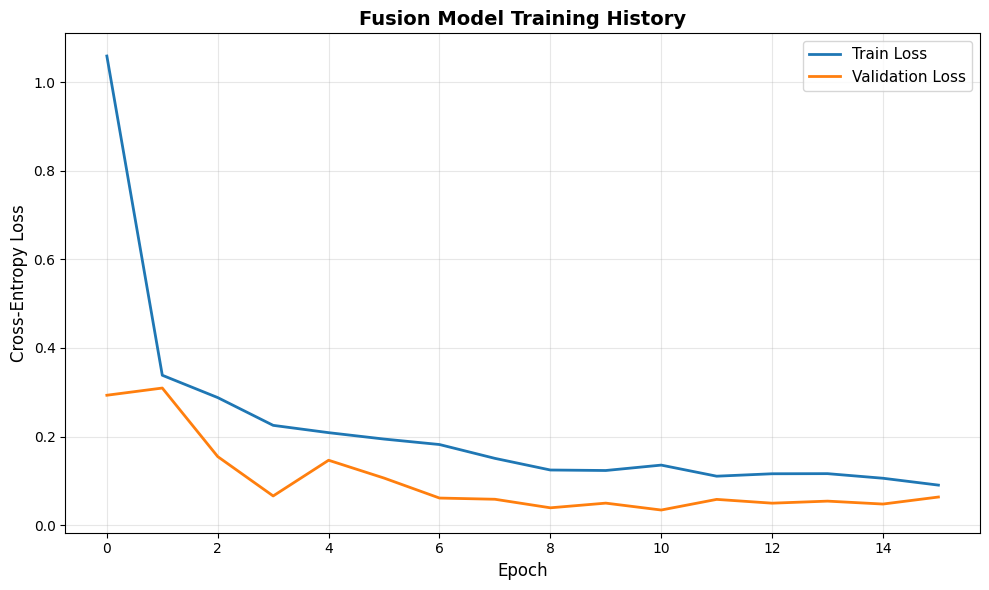

Final train loss: 0.090416
Final validation loss: 0.063547
Best validation loss: 0.034208


In [10]:
import matplotlib.pyplot as plt

# Plot training curves
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.title('Fusion Model Training History', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final train loss: {train_losses[-1]:.6f}")
print(f"Final validation loss: {val_losses[-1]:.6f}")
print(f"Best validation loss: {best_val_loss:.6f}")

## Evaluating Model

In [11]:
import numpy as np

# Load the best model
model.load_state_dict(torch.load(f"../models/{modelName}.pth"))
model.eval()

# Get all predictions and true labels from TEST set
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        
        with torch.amp.autocast("cuda"):
            logits = model(x)
        
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
print(f"Evaluated on {len(all_labels)} test samples")

Evaluated on 882 test samples


### Confusion Matrix

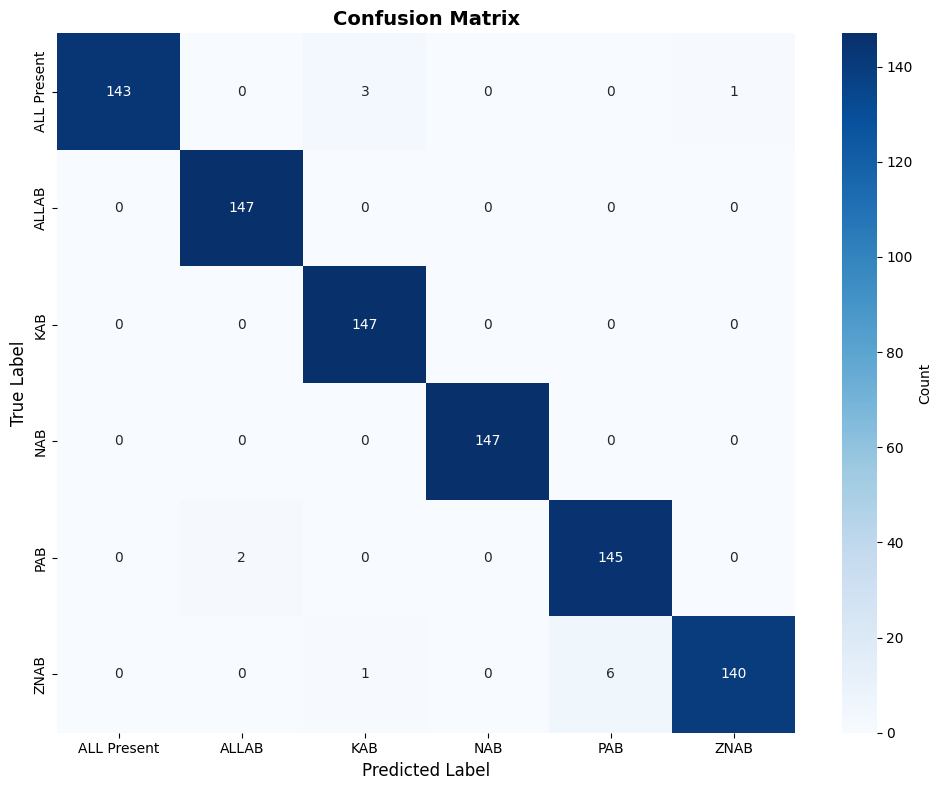

In [12]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Random Test Predictions

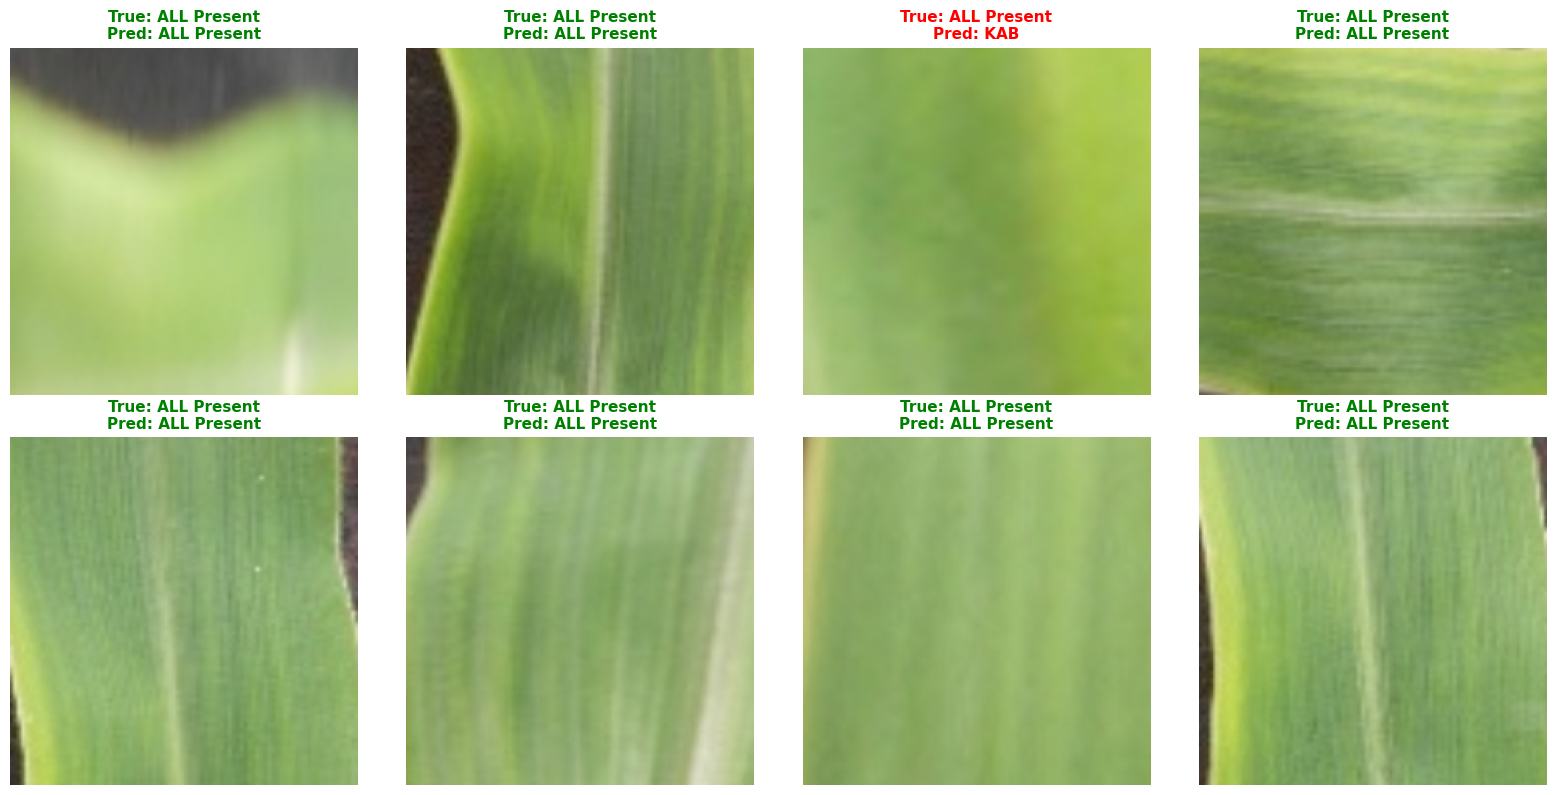

In [13]:
import random

# Get a batch of test images
test_iter = iter(test_loader)
images, labels = next(test_iter)

# Select random indices
num_samples = min(8, len(images))
random_indices = random.sample(range(len(images)), num_samples)

# Predict
images_device = images[random_indices].to(device)
with torch.no_grad():
    with torch.amp.autocast("cuda"):
        logits = model(images_device)
    predictions = torch.argmax(logits, dim=1)

# Denormalize images for visualization
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# Plot predictions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, ax in enumerate(axes[:num_samples]):
    img = images[random_indices[idx]].cpu()
    img = img * std + mean
    img = torch.clamp(img, 0, 1)
    img = img.permute(1, 2, 0).numpy()
    
    true_label = classes[labels[random_indices[idx]]]
    pred_label = classes[predictions[idx].cpu()]
    
    ax.imshow(img)
    ax.axis('off')
    
    # Color code: green for correct, red for incorrect
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', 
                 fontsize=11, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

### Getting Metrics

In [14]:
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

# Overall metrics
accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, support = precision_recall_fscore_support(all_labels, all_preds, average='weighted')

print("=" * 60)
print("OVERALL METRICS")
print("=" * 60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("\n")

# Per-class metrics
print("=" * 60)
print("PER-CLASS METRICS")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

OVERALL METRICS
Accuracy:  0.9853
Precision: 0.9855
Recall:    0.9853
F1-Score:  0.9852


PER-CLASS METRICS
              precision    recall  f1-score   support

 ALL Present     1.0000    0.9728    0.9862       147
       ALLAB     0.9866    1.0000    0.9932       147
         KAB     0.9735    1.0000    0.9866       147
         NAB     1.0000    1.0000    1.0000       147
         PAB     0.9603    0.9864    0.9732       147
        ZNAB     0.9929    0.9524    0.9722       147

    accuracy                         0.9853       882
   macro avg     0.9855    0.9853    0.9852       882
weighted avg     0.9855    0.9853    0.9852       882

